In [1]:
import all_samplers
import matplotlib.pyplot as plt
import numpy as np
import importlib as imp
import arviz as az

In [2]:
imp.reload(all_samplers)

<module 'all_samplers' from '/Users/triptesh_b/Downloads/Coursework/Research Skills/Group Project/rscam-mcmc-nonsmooth-sampling/all_samplers.py'>

In [3]:
config = all_samplers.SamplerConfig()

In [4]:

xx = np.linspace(-10, 10, 10000)
1/config.posterior(xx)
print(config.true_mean())

0.00016966099129133813
0.00016966099129133813
0.6394791193571335


Sampling...
Done Gibbs sampling
Done MYULA sampling
Done Hadamard sampling
0.00016966448072198293
0.00016966099129133813
0.00016966121329758748
0.00016966479888805817
0.00016966099129133813
0.00016966121198294505
0.00016966236351395042
0.00016966099129133813
0.00016966121344573048


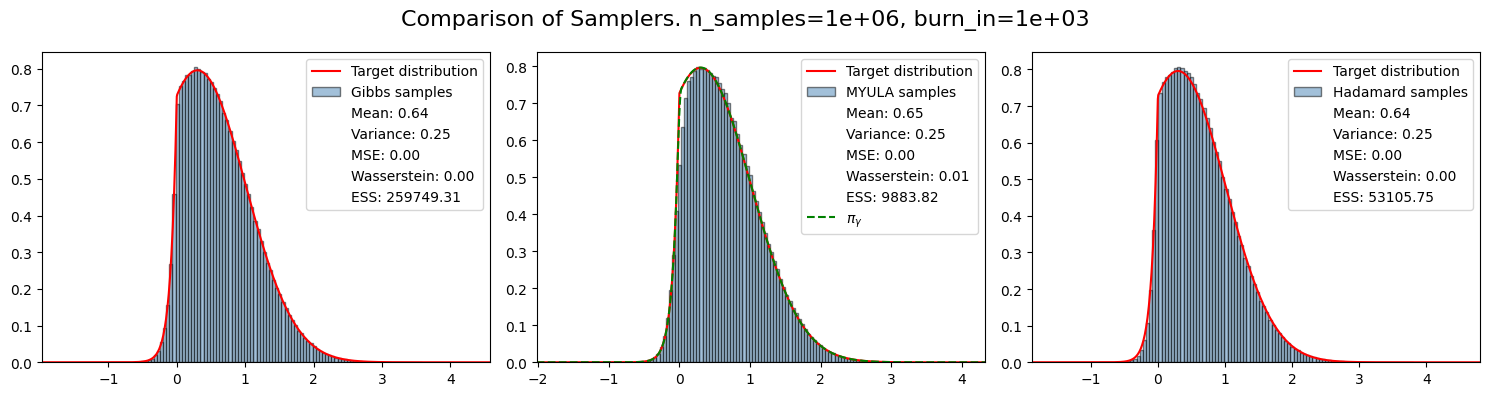

In [5]:
all_samplers.main_all()

In [6]:
gammas = np.logspace(-3, -1, 5)  # Example gamma values to test
mses = []
seconds = []
wass = []
samples = []
esss = []
mean_gamma = []
var_gamma = []
for gamma in gammas:
    sample = all_samplers.myula_sampler(gamma, config)
    mses.append(config.mse_first_moment(sample))
    seconds.append(config.mse_second_moment(sample))
    wass.append(config.wassterstein(sample))
    samples.append(sample)
    esss.append(az.ess(sample))
    mean_gamma.append(np.abs(config.true_mean() - all_samplers.true_mean_gamma(gamma, config)))
    var_gamma.append(np.abs(config.true_var() - all_samplers.true_var_gamma(gamma, config)))

0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.000169661136014732
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.0001696611569449867
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966121198294505
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966121322648488
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966121345856204
0.00016966099129133813
0.00016966099129133813


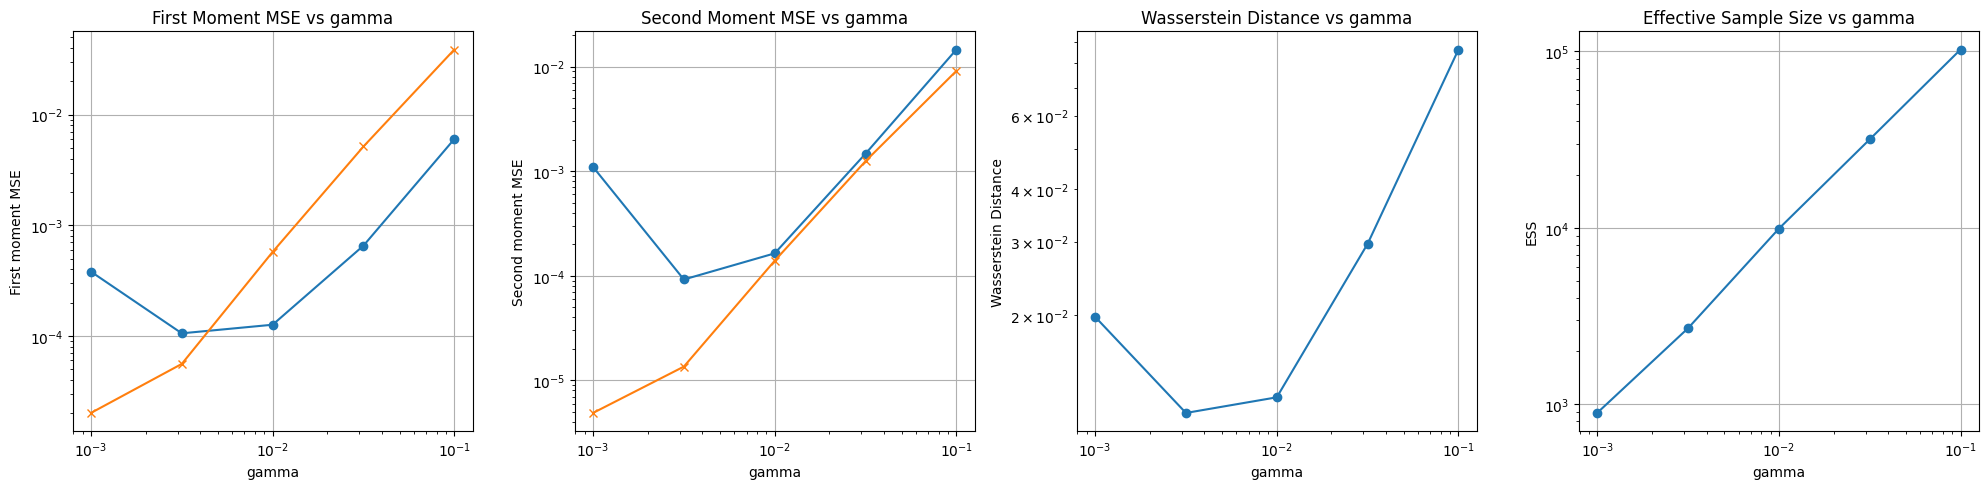

In [7]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].loglog(gammas, mses, marker='o')
axs[0].set_title('First Moment MSE vs gamma')
axs[0].set_ylabel('First moment MSE')
axs[0].loglog(gammas, mean_gamma, marker='x')
axs[1].loglog(gammas, seconds, marker='o')
axs[1].set_title('Second Moment MSE vs gamma')
axs[1].set_ylabel('Second moment MSE')
axs[1].loglog(gammas, var_gamma, marker='x')
axs[2].loglog(gammas, wass, marker='o')
axs[2].set_title('Wasserstein Distance vs gamma')
axs[2].set_ylabel('Wasserstein Distance')
axs[3].loglog(gammas, esss, marker='o')
axs[3].set_title('Effective Sample Size vs gamma')
axs[3].set_ylabel('ESS')

for ax in axs:
    ax.set_xlabel('gamma')
    # ax.set_xticklabels(np.round(gammas))
    ax.grid()
plt.tight_layout()
plt.show()

In [8]:
timesteps = np.logspace(-3, -1, 5) 
mses = []
seconds = []
wass = []
samples = []
esss = []
for h in timesteps:
    sample = all_samplers.hadamard_sampler(h, config)
    mses.append(config.mse_first_moment(sample))
    seconds.append(config.mse_second_moment(sample))
    wass.append(config.wassterstein(sample))
    samples.append(sample)
    esss.append(az.ess(sample))

0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966120483058887
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966120921548276
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.0001696612134438122
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966121344934117
0.00016966099129133813
0.00016966099129133813
0.00016966099129133813
0.00016966121346026616


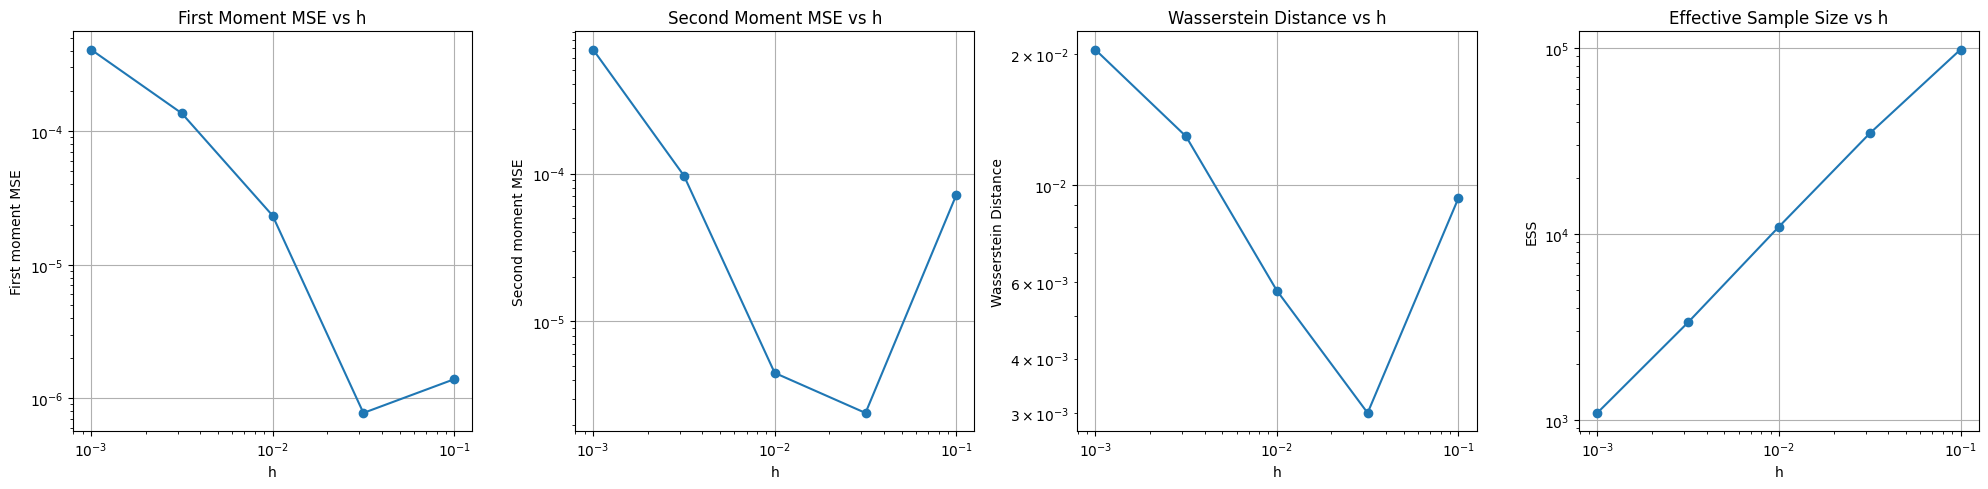

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].loglog(gammas, mses, marker='o')
axs[0].set_title('First Moment MSE vs h')
axs[0].set_ylabel('First moment MSE')
axs[1].loglog(gammas, seconds, marker='o')
axs[1].set_title('Second Moment MSE vs h')
axs[1].set_ylabel('Second moment MSE')
axs[2].loglog(gammas, wass, marker='o')
axs[2].set_title('Wasserstein Distance vs h')
axs[2].set_ylabel('Wasserstein Distance')
axs[3].loglog(gammas, esss, marker='o')
axs[3].set_title('Effective Sample Size vs h')
axs[3].set_ylabel('ESS')

for ax in axs:
    ax.set_xlabel('h')
    # ax.set_xticklabels(np.round(gammas))
    ax.grid()
plt.tight_layout()
plt.show()